In [1]:
from pathlib import Path

import random
import numpy as np
import pandas as pd
from datasets import load_from_disk

from src.utils import set_seed, print_runtime, create_folder, get_folder_size, print_message, pprint
from src.data.registry import REGISTRY
from src.data.sampler import DatasetSampler
from src.data.loader import HuggingFaceDatasetLoader
from src.data.canonical import (
    CanonicalDatasetBuilder,
    CanonicalDatasetVisualizer,
    CanonicalDatasetSerializer,
)
from src.config import CONFIG

In [2]:
print(CONFIG)

{'seed': 42, 'data': {'datasets': ['textvqa', 'gqa', 'vqav2'], 'max_size': 10000}, 'model': {'models': ['llava-hf/llava-1.5-7b-hf'], 'active_model': 'llava-hf/llava-1.5-7b-hf', 'use_4bit': True}, 'mask_strategies': {'image': ['black_image'], 'text': ['neutral_prompt']}, 'directories': {'datasets': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/data/datasets'), 'models': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/model/models'), 'results': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/results'), 'figures': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/figures'), 'checkpoints': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/checkpoints'), 'logs': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/logs')}}


In [3]:
set_seed(CONFIG["seed"])

print_runtime()

PyTorch version: 2.12.1
CUDA available: False
No GPU detected.


In [ ]:
datasets = {}
dataset_root = Path(CONFIG["directories"]["datasets"])

for dataset_key in CONFIG["data"]["datasets"]:
    dataset_config = REGISTRY[dataset_key]
    dataset_path = dataset_root / dataset_key
    loader = HuggingFaceDatasetLoader(REGISTRY, CONFIG)
    dataset = loader.load(dataset_key)
    sampler = DatasetSampler(CONFIG)
    sampled_dataset = sampler.sample(dataset)
    canonical_builder = CanonicalDatasetBuilder(dataset_key, dataset_config)
    canonical_data = canonical_builder.build_dataset(sampled_dataset)
    datasets[dataset_key] = sampler.sample(canonical_data)

Loaded dataset textvqa with 34602 samples
Created canonical dataset textvqa with 10000 samples
Loaded dataset gqa with 72140 samples
Created canonical dataset gqa with 10000 samples
Loaded dataset vqav2 with 214354 samples


TASK textvqa | Sample INDEX 654
Dataset: textvqa
Task: textvqa
Sample ID: textvqa_635
Question: who was the first owner of the de mesa-sanchez house?
Answer: antonio de mesa
All answers: ['antonio de mesa', 'antonio de mesa', 'antonia de mesa', 'antonio de mesa', 'antonio de mesa', 'mesa-sanches', 'antonio de mesa', 'antonio de mesa', 'antonio de mesa', 'antonio de mesa']
Metadata: {'raw_index': 635, 'image_id': '6d410864f7367889'}


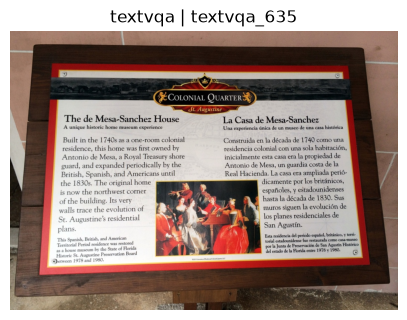

TASK gqa | Sample INDEX 114
Dataset: gqa
Task: gqa
Sample ID: gqa_276
Question: Which kind of furniture is the pillow on?
Answer: couch
All answers: ['couch']
Metadata: {'raw_index': 276, 'qa_index': 0, 'image_id': '276', 'full_answer': 'The pillow is on the couch.', 'num_available_qa_pairs': 18}


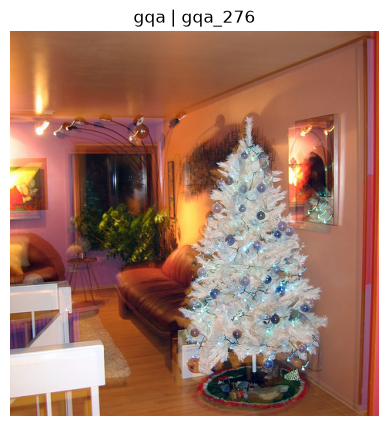

TASK vqav2 | Sample INDEX 25
Dataset: vqav2
Task: vqav2
Sample ID: vqav2_574
Question: What sport are the children playing?
Answer: frisbee
All answers: ['frisbee', 'frisbee', 'frisbee', 'frisbee', 'frisbee', 'frisbee', 'frisbee', 'soccer', 'frisbee', 'frisbee']
Metadata: {'raw_index': 574, 'image_id': '300903'}


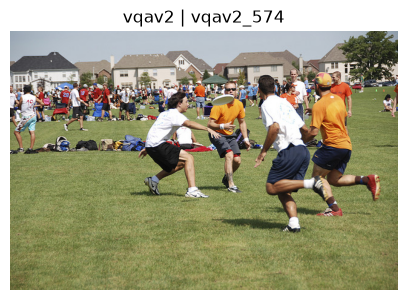

In [ ]:
canonical_visualizer = CanonicalDatasetVisualizer(datasets)

canonical_visualizer.preview_sample("textvqa", random.randint(0, len(datasets["textvqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("gqa", random.randint(0, len(datasets["gqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("vqav2", random.randint(0, len(datasets["vqav2"]) - 1), show_image=True)

In [ ]:
serializer = CanonicalDatasetSerializer(datasets)

serialized_datasets = serializer.serialize_datasets()

serializer.save_to_csv(serialized_datasets, CONFIG["directories"]["results"], "canonical_datasets")

✅ Canonical datasets saved to "/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/results/canonical_datasets.csv".


